# Geodesic Validation

Validates `geodesics.py` (Phase 2 of the Schwarzschild raytracer): weak-field deflection angle vs. the analytic `4M/b` formula, bisection convergence to the photon-sphere critical impact parameter `b_crit = 3*sqrt(3)*M`, and a visual orbit diagram across the capture/escape boundary. Figures are saved to `media/`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

import metric
import geodesics

MEDIA = "media"
os.makedirs(MEDIA, exist_ok=True)

M = metric.M_DEFAULT
b_crit = metric.b_critical(M)
print(f"M = {M}, r_horizon = {metric.r_horizon(M)}, r_photon_sphere = {metric.r_photon_sphere(M)}, b_crit = {b_crit:.6f}")

M = 1.0, r_horizon = 2.0, r_photon_sphere = 3.0, b_crit = 5.196152


## 1. Weak-field deflection angle vs. the analytic `4M/b` formula

For `b >> b_crit`, the numeric deflection should converge to the standard weak-field light-bending formula `4M/b`, with the ratio approaching 1 as `b` grows (the `4M/b` formula is only the leading term of an asymptotic series).

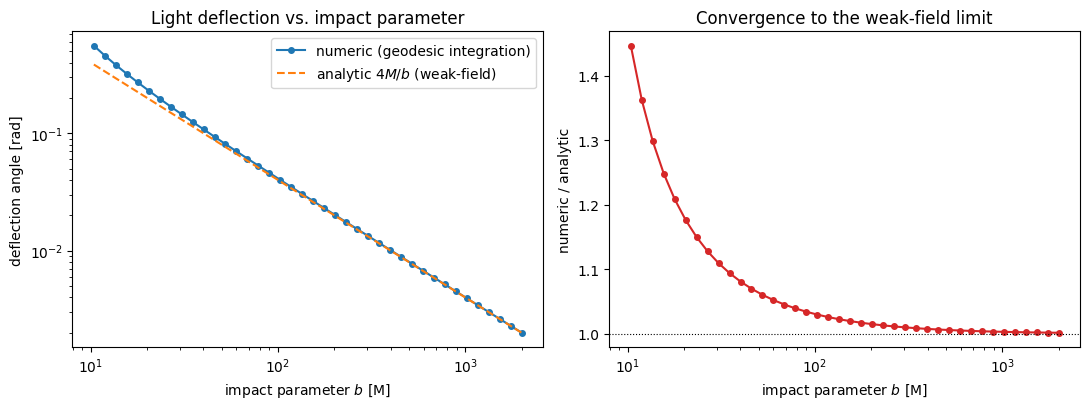

At b=2000.0M, ratio = 1.0015 (should be close to 1)


In [2]:
b_values = np.geomspace(2 * b_crit, 2000 * M, 40)
numeric = np.array([geodesics.deflection_angle(b, M) for b in b_values])
analytic = 4 * M / b_values
ratio = numeric / analytic

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].loglog(b_values, numeric, "o-", ms=4, label="numeric (geodesic integration)")
axes[0].loglog(b_values, analytic, "--", label="analytic $4M/b$ (weak-field)")
axes[0].set_xlabel("impact parameter $b$ [M]")
axes[0].set_ylabel("deflection angle [rad]")
axes[0].legend()
axes[0].set_title("Light deflection vs. impact parameter")

axes[1].semilogx(b_values, ratio, "o-", ms=4, color="tab:red")
axes[1].axhline(1.0, color="k", lw=0.8, ls=":")
axes[1].set_xlabel("impact parameter $b$ [M]")
axes[1].set_ylabel("numeric / analytic")
axes[1].set_title("Convergence to the weak-field limit")

fig.tight_layout()
fig.savefig(os.path.join(MEDIA, "deflection_angle_validation.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"At b={b_values[-1]:.1f}M, ratio = {ratio[-1]:.4f} (should be close to 1)")

## 2. Photon-sphere bracketing

Bisecting on the impact parameter `b` for a ray aimed inward should converge exactly to `b_crit = 3*sqrt(3)*M`: rays with `b` below it fall into the horizon, rays above it escape (after whirling close to the unstable photon sphere at `r=3M` the closer `b` gets to `b_crit`).

bisection converged b = 5.1961524227
analytic b_crit      = 5.1961524227
relative error       = 0.00e+00


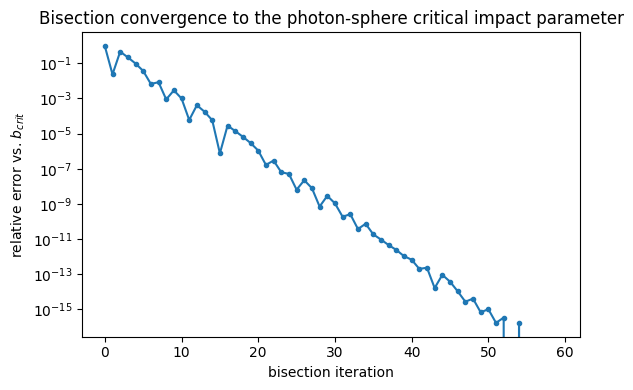

In [3]:
r0 = 10.0 * M
lo, hi = 0.1 * M, 20.0 * M
history = []
for _ in range(60):
    mid = 0.5 * (lo + hi)
    res = geodesics.integrate_ray(r0, 0.0, mid, sign0=-1, M=M, phi_max=200 * np.pi, max_step=5e-3)
    if res["outcome"] == "horizon":
        lo = mid
    else:
        hi = mid
    history.append(mid)

history = np.array(history)
b_bisect = history[-1]
print(f"bisection converged b = {b_bisect:.10f}")
print(f"analytic b_crit      = {b_crit:.10f}")
print(f"relative error       = {abs(b_bisect - b_crit) / b_crit:.2e}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(np.abs(history - b_crit) / b_crit, "o-", ms=3)
ax.set_xlabel("bisection iteration")
ax.set_ylabel("relative error vs. $b_{crit}$")
ax.set_title("Bisection convergence to the photon-sphere critical impact parameter")
fig.tight_layout()
fig.savefig(os.path.join(MEDIA, "photon_sphere_bisection.png"), dpi=150, bbox_inches="tight")
plt.show()

## 3. Orbit diagram

A family of rays fired inward from the same starting radius with impact parameters straddling `b_crit`: strongly bent but escaping (large `b`), whirling near the photon sphere close to `b_crit`, and captured (small `b`).

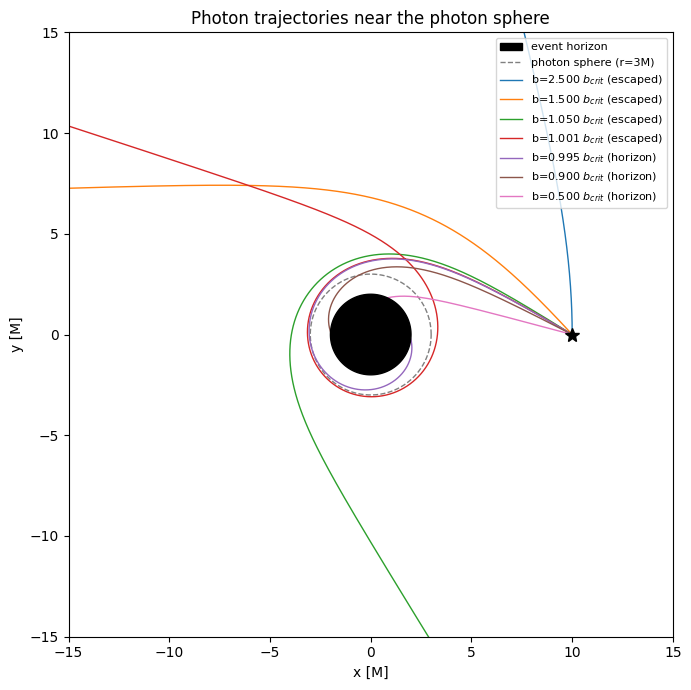

In [4]:
r0 = 10.0 * M
b_list = [b_crit * f for f in (2.5, 1.5, 1.05, 1.001, 0.995, 0.9, 0.5)]

fig, ax = plt.subplots(figsize=(7, 7))

theta_circle = np.linspace(0, 2 * np.pi, 200)
ax.fill(metric.r_horizon(M) * np.cos(theta_circle), metric.r_horizon(M) * np.sin(theta_circle),
        color="black", zorder=5, label="event horizon")
ax.plot(metric.r_photon_sphere(M) * np.cos(theta_circle), metric.r_photon_sphere(M) * np.sin(theta_circle),
        "--", color="gray", lw=1, label="photon sphere (r=3M)")

for b in b_list:
    res = geodesics.integrate_ray(r0, 0.0, b, sign0=-1, M=M, phi_max=60 * np.pi, max_step=5e-3)
    r = 1.0 / res["u"]
    phi = res["phi"]
    x, y = r * np.cos(phi), r * np.sin(phi)
    ax.plot(x, y, lw=1, label=f"b={b/b_crit:.3f} $b_{{crit}}$ ({res['outcome']})")

ax.plot(r0, 0, "k*", ms=10, zorder=6)
lim = 15 * M
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_aspect("equal")
ax.set_xlabel("x [M]")
ax.set_ylabel("y [M]")
ax.legend(fontsize=8, loc="upper right")
ax.set_title("Photon trajectories near the photon sphere")
fig.tight_layout()
fig.savefig(os.path.join(MEDIA, "orbit_diagram.png"), dpi=150, bbox_inches="tight")
plt.show()

## 4. Conservation check

The impact parameter `b` is a conserved quantity of the orbit; recomputing it from the numerical `(u, du/dphi)` at every integration point should reproduce the input `b` to high precision along the whole trajectory.

input b = 7.0, recovered b range = [7.00000000, 7.00000000]
max relative error along trajectory = 2.89e-14


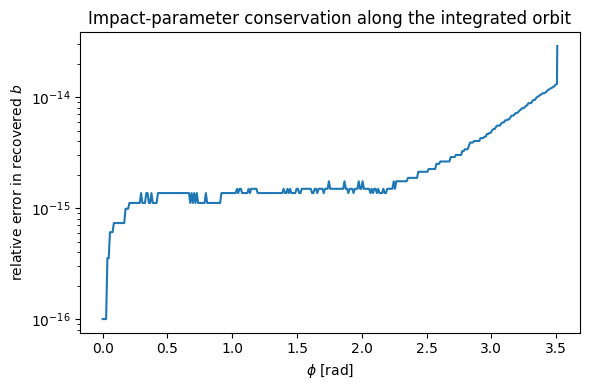

In [5]:
b_input = 7.0 * M
res = geodesics.integrate_ray(10.0 * M, 0.0, b_input, sign0=-1, M=M, max_step=1e-2)
u, up = res["u"], res["up"]
b_local = 1.0 / np.sqrt(up**2 + u**2 * (1 - 2 * M * u))

rel_err = np.abs(b_local - b_input) / b_input
print(f"input b = {b_input}, recovered b range = [{b_local.min():.8f}, {b_local.max():.8f}]")
print(f"max relative error along trajectory = {rel_err.max():.2e}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(res["phi"], rel_err + 1e-16)
ax.set_xlabel("$\\phi$ [rad]")
ax.set_ylabel("relative error in recovered $b$")
ax.set_title("Impact-parameter conservation along the integrated orbit")
fig.tight_layout()
fig.savefig(os.path.join(MEDIA, "conservation_check.png"), dpi=150, bbox_inches="tight")
plt.show()

## 5. Camera + geodesic pipeline preview (Phase 3)

Sanity check that `camera.py`'s pinhole ray generation feeds correctly into `geodesics.py`: a fan of rays from a tilted camera (looking down at the disk plane, `theta_cam=60deg`), colored by outcome (captured vs. escaped), reconstructed into 3D via `camera.plane_to_3d`.

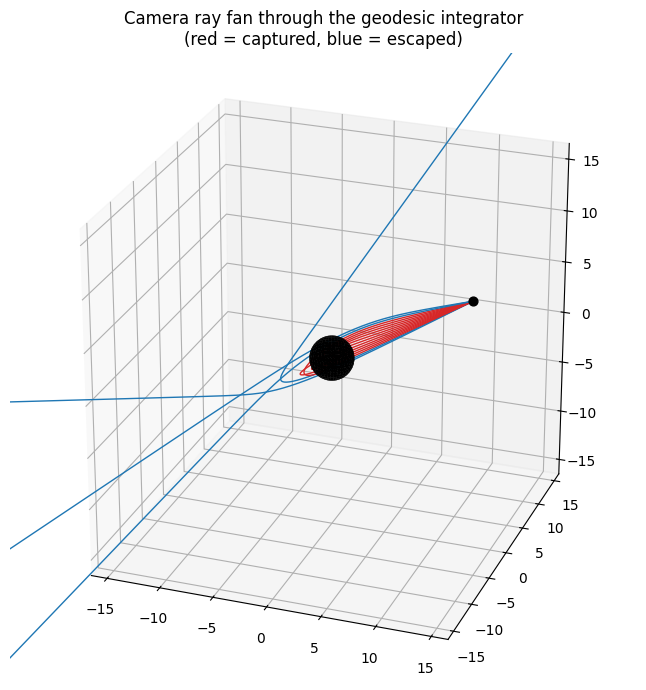

In [6]:
import camera
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

r_cam = 15.0 * M
theta_cam = np.radians(60)
pos = camera.camera_position(r_cam, theta_cam, 0.0)
forward, right, up = camera.camera_basis(pos)

n_rays = 15
dirs = camera.pixel_directions((n_rays, 1), fov_deg=50, forward=forward, right=right, up=up)[0]

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(projection="3d")

u_sphere, v_sphere = np.mgrid[0:2 * np.pi:40j, 0:np.pi:20j]
r_h = metric.r_horizon(M)
ax.plot_surface(
    r_h * np.cos(u_sphere) * np.sin(v_sphere),
    r_h * np.sin(u_sphere) * np.sin(v_sphere),
    r_h * np.cos(v_sphere),
    color="black",
)

for d in dirs:
    b, sign0, e1, e2 = camera.ray_setup(d, pos, M)
    if b < 1e-8:
        traj = np.array([pos, np.zeros(3)])
        outcome = "horizon"
    else:
        res = geodesics.integrate_ray(r_cam, 0.0, b, sign0, M=M, max_step=1e-2)
        outcome = res["outcome"]
        traj = camera.plane_to_3d(1.0 / res["u"], res["phi"], e1, e2)
    color = "tab:red" if outcome == "horizon" else "tab:blue"
    ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], color=color, lw=1)

ax.scatter(*pos, color="k", s=40)
lim = r_cam * 1.1
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_zlim(-lim, lim)
ax.set_box_aspect([1, 1, 1])
ax.view_init(elev=25, azim=-70)
ax.set_title("Camera ray fan through the geodesic integrator\n(red = captured, blue = escaped)")
fig.tight_layout()
fig.savefig(os.path.join(MEDIA, "camera_ray_fan.png"), dpi=150, bbox_inches="tight")
plt.show()